### Problem Statement:
The goal is to predict loan default risks using the Kaggle Loan Prediction Dataset. By cleaning applicant data and analyzing key features like income and loan amount, a classification model will be trained. The model's success will be evaluated using accuracy and a confusion matrix to identify high-risk borrowers.

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

loan = pd.read_csv("original_dataset.csv")

In [37]:
print(f"shape of dataset: {loan.shape}\n")
print(f"columns of dataset:\n{loan.columns}\n")
print(f"missing values in dataset:\n{loan.isnull().sum()}\n")
print(f"duplicated values in dataset: {loan.duplicated().sum()}\n")
print(f"datatypes of dataset:\n{loan.dtypes}\n")
print(f"Top 5 Data:\n{loan.head()}\n")

shape of dataset: (20000, 22)

columns of dataset:
Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

missing values in dataset:
age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance       

Observation: Dataset contains 20,000 rows and 22 columns. No missing values or duplicates found. All datatypes are correct.

In [38]:
# Using a for loop to count value frequencies for all categorical columns
print(loan.describe())
print(f"values counts of categorical columns:\n")
for col in loan.columns:
    if loan[col].dtypes == 'object':
        print(loan[col].value_counts())


                age  annual_income  monthly_income  debt_to_income_ratio  \
count  20000.000000   20000.000000    20000.000000          20000.000000   
mean      48.027000   43549.637766     3629.136466              0.177019   
std       15.829352   28668.579671     2389.048326              0.105059   
min       21.000000    6000.000000      500.000000              0.010000   
25%       35.000000   24260.752500     2021.730000              0.096000   
50%       48.000000   36585.260000     3048.770000              0.160000   
75%       62.000000   54677.917500     4556.495000              0.241000   
max       75.000000  400000.000000    33333.330000              0.667000   

       credit_score   loan_amount  interest_rate    loan_term   installment  \
count   20000.00000  20000.000000   20000.000000  20000.00000  20000.000000   
mean      679.25695  15129.300909      12.400626     43.22280    455.625794   
std        69.63858   8605.405513       2.442729     11.00838    274.622125   

<h5> Observation: The dataset is imbalanced  79.9% applicants paid back (15,998) and 20.1% defaulted (4,002). Credit score is normally distributed with mean 679. Annual income, total credit limit, and current balance are right-skewed with high-value outliers. Delinquency features show extreme outliers, 75th percentile is 3 but max reaches 11. <h5/>

In [39]:
# Choosing columns to visualize which have high correlation with the target variable
print(loan.corr(numeric_only=True)['loan_paid_back'].sort_values())

debt_to_income_ratio   -0.223831
interest_rate          -0.110935
delinquency_history    -0.084940
num_of_delinquencies   -0.070896
installment            -0.010068
current_balance        -0.004749
total_credit_limit     -0.002985
loan_term              -0.002615
loan_amount            -0.002490
num_of_open_accounts    0.002964
annual_income           0.003057
monthly_income          0.003057
public_records          0.003210
age                     0.007999
credit_score            0.199841
loan_paid_back          1.000000
Name: loan_paid_back, dtype: float64


In [40]:
print(loan.groupby('gender')['loan_paid_back'].mean())
print(loan.groupby('marital_status')['loan_paid_back'].mean())
print(loan.groupby('loan_purpose')['loan_paid_back'].mean())
print(loan.groupby('education_level')['loan_paid_back'].mean())
print(loan.groupby('employment_status')['loan_paid_back'].mean())

gender
Female    0.802472
Male      0.797504
Other     0.793023
Name: loan_paid_back, dtype: float64
marital_status
Divorced    0.805322
Married     0.800312
Single      0.799579
Widowed     0.784832
Name: loan_paid_back, dtype: float64
loan_purpose
Business              0.809085
Car                   0.798326
Debt consolidation    0.799399
Education             0.777910
Home                  0.824037
Medical               0.782609
Other                 0.802745
Vacation              0.792422
Name: loan_paid_back, dtype: float64
education_level
Bachelor's     0.791299
High School    0.808076
Master's       0.797798
Other          0.803714
PhD            0.828358
Name: loan_paid_back, dtype: float64
employment_status
Employed         0.886984
Retired          0.994898
Self-employed    0.885734
Student          0.407170
Unemployed       0.181732
Name: loan_paid_back, dtype: float64


<h5> Observation(eature Selection): Correlation was used for numerical columns and groupby mean for categorical columns to identify important features. debt_to_income_ratio (-0.22) and credit_score (0.19) are the strongest numerical predictors. interest_rate (-0.11) shows moderate correlation. Remaining numerical columns show near-zero correlation and are weak predictors. For categorical columns, employment_status shows the strongest signal, Unemployed (0.18) and Student (0.40) have significantly lower payback rates compared to Employed (0.88) and Retired (0.99), a difference of 0.70. Gender, marital status, loan purpose, and education level show less than 0.05 difference across categories and are weak predictors." <h5/>

### Visualization ###

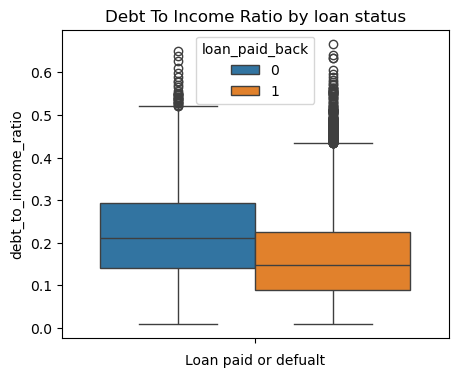

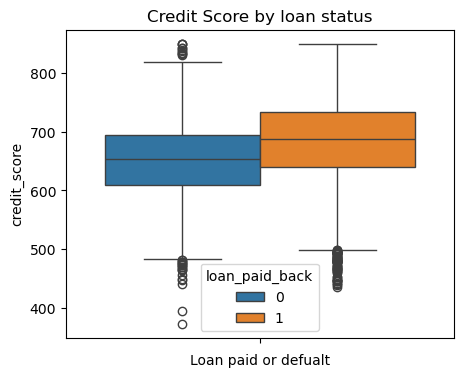

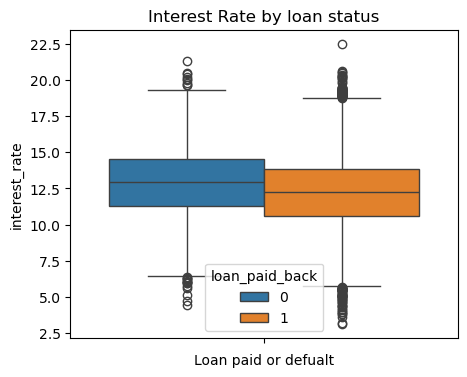

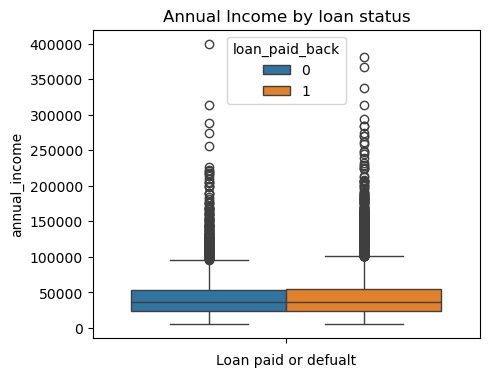

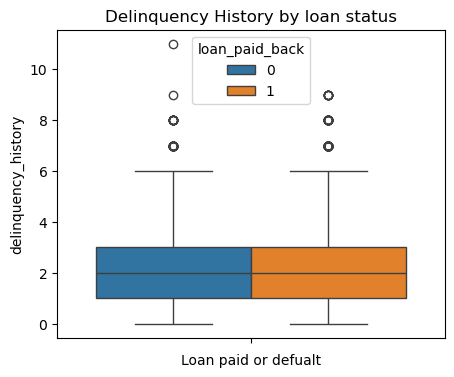

In [41]:
# Univariate analysis of numerical columns using boxplots with a for loop
num_columns = ["debt_to_income_ratio", "credit_score", "interest_rate", "annual_income", "delinquency_history"]

for col in num_columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(data=loan, y=col, hue="loan_paid_back")
    plt.xlabel("Loan paid or defualt")
    plt.title(f"{col.replace('_', ' ').title()} by loan status")
    plt.show()

#### Numerical graph Observations:

due to income ratio by loan status:
Defaulters show a higher median ratio (0.21) compared to paid-back applicants (0.15), higher debt burden increases default risk. Outliers exist in both groups above 0.45..

creadit score by loan status:
Paid-back applicants have a higher median credit score (~680) vs defaulters (~650), confirming positive correlation (0.19). Some low-score applicants still paid back, suggesting credit score alone is insufficient..

interest rate by loan status:
Defaulters show slightly higher median interest rate (13%) vs paid-back (12%). Difference is small, interest rate alone is not a strong predictor..

annual income by loan status:
Both groups show similar median income, confirming weak correlation (0.003). Significant outliers exist above $300,000 in both groups. Raw income is less useful than debt-to-income ratio..

Delinquency history by loan status:
Both groups show same median (2) with similar outliers confirms weak correlation (-0.08). Payment history alone cannot distinguish defaulters.


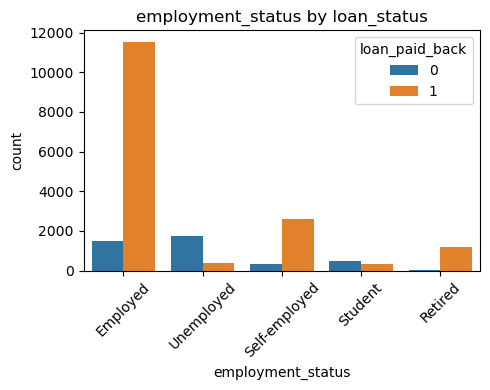

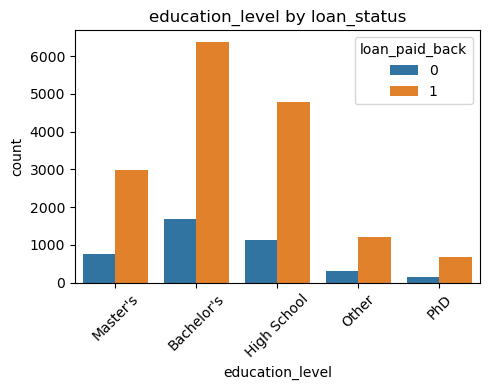

In [42]:
# Visualizing this graph because we already observed a big difference between these categories
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x="employment_status", hue="loan_paid_back")
plt.title("employment_status by loan_status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualizing this column because it was specifically requested in the project tasks
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x="education_level", hue="loan_paid_back")
plt.xticks(rotation=45)
plt.title("education_level by loan_status")
plt.tight_layout()

plt.show()

#### categorical graph Observations:

employment Status by loan status:
Employed and Self-employed applicants show significantly higher payback rates. Unemployed applicants have more defaults than paybacks highest risk group. Retired applicants almost never default (0.99). Students are moderate risk (0.40).

education level by loan status:
All education levels show similar payback-to-default ratios (0.79–0.83). Education is not a meaningful predictor of loan default.

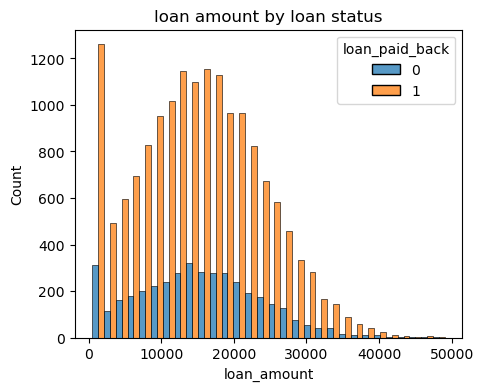

In [43]:
# Histogram displaying the distribution of loan amounts across paid and defaulted loans using side-by-side bars
plt.figure(figsize=(5,4))
sns.histplot(data=loan, x="loan_amount", hue="loan_paid_back", multiple="dodge", bins= 30)
plt.title("loan amount by loan status")
plt.show()

#### observation:

loan amount by loan status
Distribution is right-skewed  most loans fall in $5,000–$20,000 range. No clear pattern between loan amount and default risk, confirming weak correlation (-0.002)

In [44]:
# Column selection and categorical encoding

# Selecting features and target variable for the model
model_df = loan[['debt_to_income_ratio', 'credit_score','interest_rate', 'employment_status', 'loan_paid_back']]

# Encoding employment_status using dummy variables ( called one hot encoding)
model_df = pd.get_dummies(model_df, columns=['employment_status'], drop_first=True, dtype=int)

print(model_df.head())
print(model_df.shape)

   debt_to_income_ratio  credit_score  interest_rate  loan_paid_back  \
0                 0.074           743          13.39               1   
1                 0.219           531          17.81               1   
2                 0.234           779           9.53               1   
3                 0.264           809           7.99               1   
4                 0.260           663          15.20               1   

   employment_status_Retired  employment_status_Self-employed  \
0                          0                                0   
1                          0                                0   
2                          0                                0   
3                          0                                0   
4                          0                                0   

   employment_status_Student  employment_status_Unemployed  
0                          0                             0  
1                          0                          

In [24]:
# Scaling columns so that the model performs well
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
model_df["credit_score"] = scaler.fit_transform(model_df[["credit_score"]])
model_df["debt_to_income_ratio"] = scaler.fit_transform(model_df[["debt_to_income_ratio"]])
model_df["interest_rate"] = scaler.fit_transform(model_df[["interest_rate"]])


<h2 style="text-align: center;">Machine learning</h2>


#### Logistic Regression:


In [ ]:
#  Logistic Regression modeling and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# Defining features and target, splitting into training and testing sets, and calculating evaluation metrics
X = model_df.drop(columns="loan_paid_back")
y = model_df["loan_paid_back"]

# Initializing and training the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()

# Making predictions on the test dataset
model.fit(X_train, y_train)
pred = model.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
loan_precision = precision_score(y_test, pred, pos_label=0)  # defaulters
loan_recall = recall_score(y_test, pred, pos_label=0)        # defaulters

# Displaying evaluation results
print(f"Model Accuracy: {accuracy}\n")
print(f"Model Confusion Matrix:\n{cm}\n")
print(f"Loan Precision Score = {loan_precision}")
print(f"Loan Recall Score = {loan_recall}")

Model Accuracy: 0.88

Model Confusion Matrix:
[[ 465  353]
 [ 127 3055]]

Loan Precision Score = 0.785472972972973
Loan Recall Score = 0.5684596577017115


#### Trying Logistic Regression with Smote

In [53]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

model = LogisticRegression()
model.fit(X_resampled, y_resampled)
pred = model.predict(X_test)

cm = confusion_matrix(y_test, pred)

print(classification_report(y_test, pred))
print(f"Confusion Matrix:\n{cm}")

              precision    recall  f1-score   support

           0       0.52      0.74      0.61       818
           1       0.93      0.82      0.87      3182

    accuracy                           0.81      4000
   macro avg       0.72      0.78      0.74      4000
weighted avg       0.84      0.81      0.82      4000

Confusion Matrix:
[[ 608  210]
 [ 558 2624]]


#### Model observation:
 Our goal was to identify loan defaulters (class 0). Logistic Regression achieved 88% accuracy but missed 353 defaulters (defaulter recall = 0.57) significant financial risk for the bank. Since missing a defaulter is more costly than a false alarm, we applied SMOTE to balance the training data. After SMOTE, defaulter recall improved from 0.57 to 0.72, meaning more high-risk borrowers were correctly identified. Although precision dropped and overall accuracy decreased slightly to 81%, this tradeoff is acceptable given the business goal of catching defaulters. Future improvement can be done using threshold tuning or ensemble methods.

#### Conclusion: 
The goal was to predict loan default risk. The dataset had 20,000 rows and 22 columns with no missing values or duplicates. The target variable was imbalanced  79.9% paid back and 20.1% defaulted.
Through correlation and groupby analysis, debt_to_income_ratio (-0.22), credit_score (0.19), interest_rate (-0.11), and employment_status (unemployed=0.18, retired=0.99) were identified as the strongest predictors. Weak predictors like gender, marital status, and education level were excluded.
Visualizations confirmed these findings  defaulters had higher debt ratios, lower credit scores, and unemployed applicants showed the highest default rate.
For modeling, employment_status was one-hot encoded and numerical features were scaled. Logistic Regression achieved 88% accuracy but defaulter recall was only 0.57  too many defaulters were missed. After applying SMOTE to handle class imbalance, defaulter recall improved to 0.72, making the model more suitable for identifying high-risk borrowers. The tradeoff was lower precision (0.52) and accuracy (0.81), which is acceptable since missing a defaulter is more costly than a false alarm for the bank."